In [ ]:
%load_ext autoreload
%autoreload 2
from finsler_embedding.experiment_run import *
from geodesic_toolbox.cometric import CentroidsCometric, IdentityCoMetric
from geodesic_toolbox.utils import get_mf_image
from sklearn.manifold import Isomap, SpectralEmbedding
import pandas as pd
import seaborn as sns

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
def sample_uniform2D(n_samples, bounds=[[-1, 1], [-1, 1]]):
    """
    Sample points uniformly in a 2D rectangle defined by bounds.
    """
    x_min, x_max = bounds[0]
    y_min, y_max = bounds[1]
    x_samples = torch.rand(n_samples) * (x_max - x_min) + x_min
    y_samples = torch.rand(n_samples) * (y_max - y_min) + y_min
    return torch.stack((x_samples, y_samples), dim=1)

In [3]:
base_cometric = IdentityCoMetric()
beta= .6
omega_true=  get_omega(omega_type="random",cometric=base_cometric)
randers_metric = RandersMetrics(omega=omega_true, base_cometric=base_cometric, beta=beta)

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4221.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


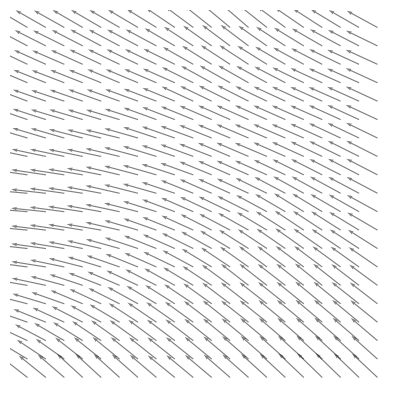

In [4]:
x_mesh = torch.linspace(-1, 1, 20)
y_mesh = torch.linspace(-1, 1, 20)
X_mesh, Y_mesh = torch.meshgrid(x_mesh, y_mesh)
grid_pts = torch.stack((X_mesh.flatten(), Y_mesh.flatten()), dim=1)
omega_grid = omega_true(grid_pts).detach()

fig, ax = plt.subplots(figsize=(6, 5))
# ax.scatter(grid_pts.detach().numpy()[:, 0], grid_pts.detach().numpy()[:, 1])
ax.quiver(
    grid_pts[:, 0].detach().cpu(),
    grid_pts[:, 1].detach().cpu(),
    omega_grid[:, 0].detach().cpu(),
    omega_grid[:, 1].detach().cpu(),
    color="black",
    scale=5,
    alpha=0.5,
    angles="xy",
    scale_units="xy"
)
ax.axis("off")
ax.set_aspect("equal")

In [ ]:
import tqdm
import itertools
N = 100
m=2
K = 500
N_values = [20, 50, 100, 200, 400, 800, 1600]
n_tries = 5
frames = []

for N, tries_nb in tqdm.tqdm(itertools.product(N_values, range(n_tries)), total=len(N_values)*n_tries):
        X = sample_uniform2D(N)

        edges = get_knn_graph(X, n_neighbors=10,device="cpu")
        LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
        dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True,pbar=False)


        epsilon = compute_epsilon_empirical(dst_edges,scale=1)


        W, mu_0, mu_1 = gaussian_kernel(edges, dst_edges, epsilon, N, m)
        c_km = -mu_1 / mu_0 * (m + 1) / m

        Q_inv_theta = get_Q_inv_theta(W, theta=1)
        W_theta_s, W_theta_a = get_W_thetas(W, Q_inv_theta)
        P_theta_s, P_theta_a = construct_P_thetas(W_theta_s, W_theta_a)
        L_theta_s = 1 / epsilon**2 * P_theta_s
        L_theta_a = 1 / epsilon * P_theta_a

        f_values, Lf_values, f_grad_values = prepare_test_functions(
                K, "coordinates", X, L_theta_a
            )

        b_true = randers_metric.omega(X).detach() * randers_metric.beta
        v_true = b_to_v(b_true, base_cometric.cometric_tensor(X))
        true_rhs = c_km * torch.einsum('n d, k n d -> k n', v_true, f_grad_values)  # (K, N)
        error_operator = (Lf_values - true_rhs).pow(2).mean()


        v_model, omega_model, loss_list = train_vector_field_models(
            X, base_cometric, c_km, f_values, Lf_values, f_grad_values,pbar=False
        )

        v_hat_deep = v_model(X).detach()
        b_hat_deep = omega_model(X).detach()
        # fig, axes = plot_side_by_side(X,b_true, b_hat_deep,skip=1, scale_b=.2, scale_bhat=0.0005)
        cosim = torch.nn.CosineSimilarity(dim=1, eps=1e-6)(b_true, b_hat_deep)
        new_df = {"cosim": cosim.detach().numpy(), "N": N, "tries_nb": tries_nb, "error_operator": error_operator.detach().numpy()}
        frames.append(pd.DataFrame(new_df))

res = pd.concat(frames)

  0%|          | 0/35 [00:00<?, ?it/s]

[2026-09-16 19:09:27] - INFO - Found 248 edges in the KNN graph.


  3%|▎         | 1/35 [00:01<00:50,  1.48s/it]

[2026-09-16 19:09:28] - INFO - Found 234 edges in the KNN graph.


  6%|▌         | 2/35 [00:02<00:39,  1.20s/it]

...

 94%|█████████▍| 33/35 [00:35<00:02,  1.17s/it]

[2026-09-16 19:10:02] - INFO - Found 18356 edges in the KNN graph.


 97%|█████████▋| 34/35 [00:36<00:01,  1.17s/it]

[2026-09-16 19:10:03] - INFO - Found 18398 edges in the KNN graph.


100%|██████████| 35/35 [00:37<00:00,  1.07s/it]


[2026-09-16 19:10:04] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


[2026-09-16 19:10:04] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


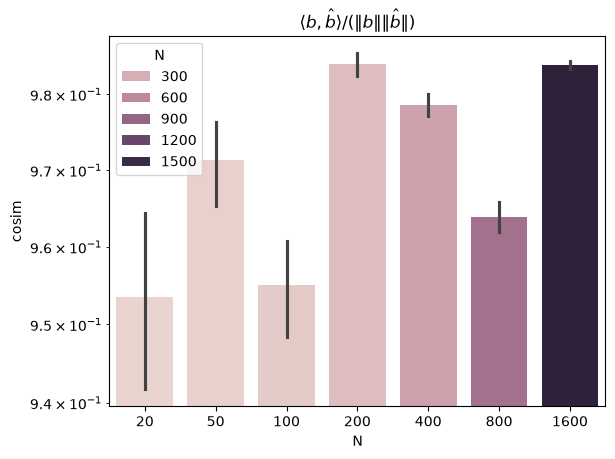

[2026-09-16 19:10:05] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-16 19:10:05] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


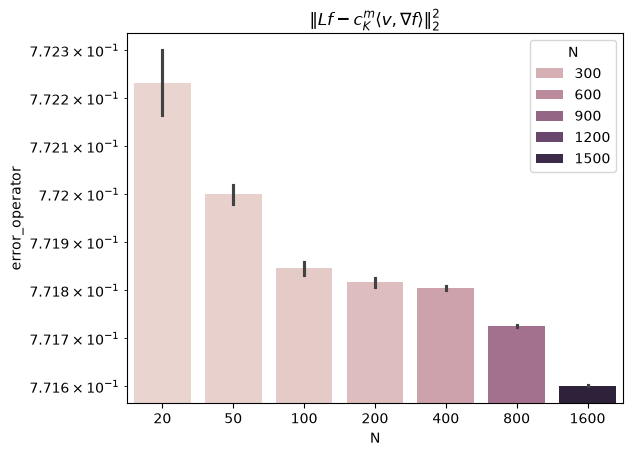

In [124]:

sns.barplot(data=res, x="N", y="cosim",hue="N")
plt.gca().set_yscale("log")
plt.title(r"$\langle b, \hat{b} \rangle / (\|b\| \|\hat{b}\|)$")
plt.show()

sns.barplot(data=res, x="N", y="error_operator",hue="N")
plt.gca().set_yscale("log")
plt.title(r"$\|Lf - c_K^m \langle v, \nabla f \rangle \|^2_2$")
plt.show()

[2026-09-16 19:10:05] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


[2026-09-16 19:10:05] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-16 19:10:05] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-16 19:10:05] - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


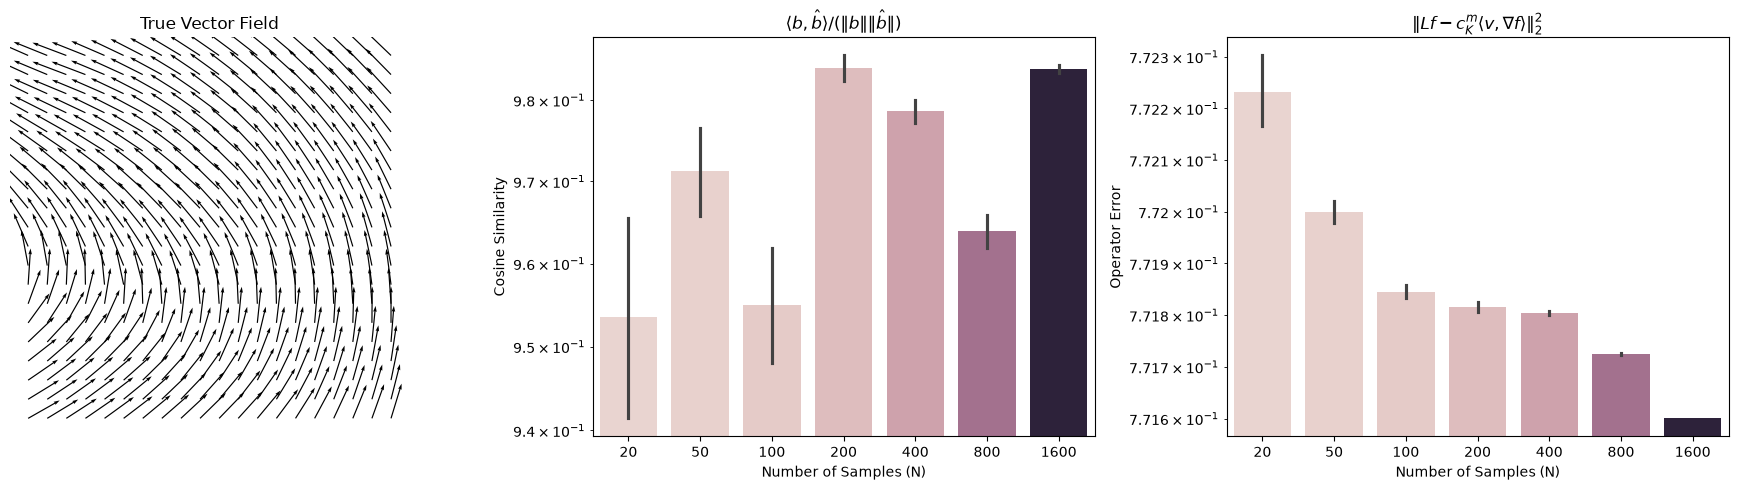

In [125]:
# Aggregate convergence plots and true vector field
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].quiver(
    grid_pts[:, 0].detach().cpu(),
    grid_pts[:, 1].detach().cpu(),
    omega_grid[:, 0].detach().cpu(),
    omega_grid[:, 1].detach().cpu(),
    color="black",
    scale=5,
    angles="xy",
    scale_units="xy"
)
axes[0].set_title("True Vector Field")
axes[0].axis("off")
axes[0].set_aspect("equal")

sns.barplot(data=res, x="N", y="cosim",hue="N", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title(r"$\langle b, \hat{b} \rangle / (\|b\| \|\hat{b}\|)$")
axes[1].legend().remove()
axes[1].set_xlabel("Number of Samples (N)")
axes[1].set_ylabel("Cosine Similarity")

sns.barplot(data=res, x="N", y="error_operator",hue="N", ax=axes[2])
axes[2].set_yscale("log")
axes[2].set_title(r"$\|Lf - c_K^m \langle v, \nabla f \rangle \|^2_2$")
axes[2].legend().remove()
axes[2].set_xlabel("Number of Samples (N)")
axes[2].set_ylabel("Operator Error")

plt.tight_layout()
plt.savefig("./convergence_analysis.pdf", dpi=300)